In [54]:
!pip install torchmetrics optuna torchaudio

In [55]:
import torch
import torchmetrics
import torch.nn as nn
import torchvision

In [56]:
import numpy as np
import matplotlib.pyplot as plt

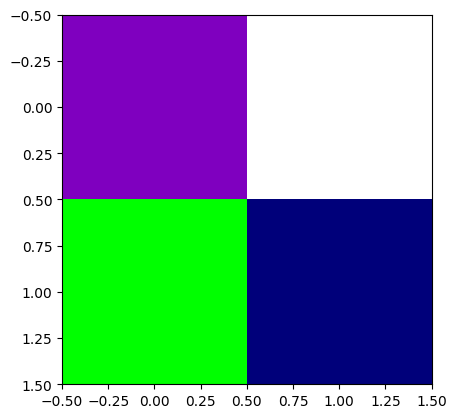

In [57]:
img_array = np.array([
    [
        [127,255], # R
    	[0,0],
    ],
    [
        [0,255], # G
    	[255,0],
    ],
    [
        [191,255], # B
    	[0,122],
    ],
])
plt.imshow(img_array.transpose(1,2,0))
plt.show()

In [58]:
(1,32,32)
(32,32,1)

(32, 32, 1)

In [59]:
from sklearn.datasets import load_sample_images

In [61]:
sample_images = load_sample_images()['images']
len(sample_images)

2

(427, 640, 3)


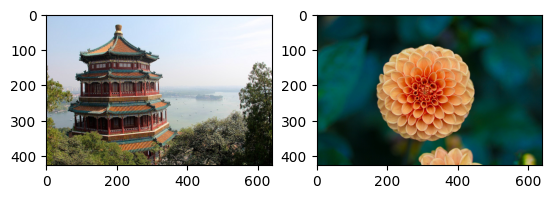

In [65]:
print(sample_images[0].shape)

fig,axs = plt.subplots(1,2)
axs[0].imshow(sample_images[0])
axs[1].imshow(sample_images[1])

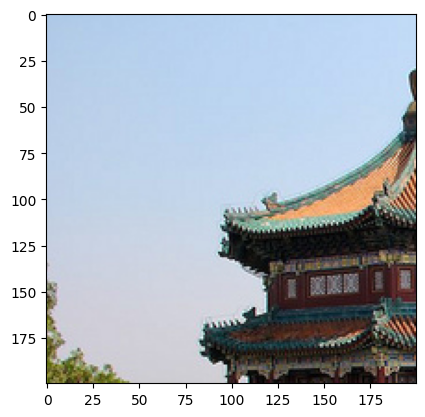

In [69]:
plt.imshow(sample_images[0][:200, :200, ...])

In [77]:
sample_images = np.stack(sample_images)
sample_images.shape

(2, 427, 640, 3)

(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

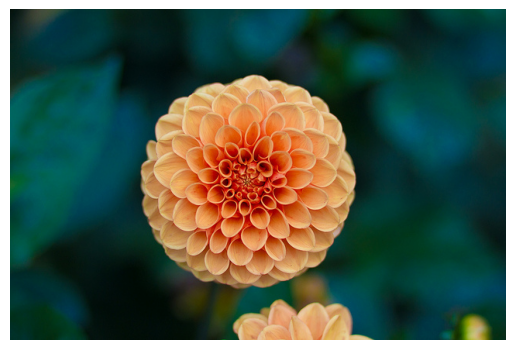

In [103]:
plt.imshow(sample_images[1, ...])
plt.axis("off")

In [84]:
sample_images.shape

(2, 427, 640, 3)

In [88]:
sample_images.transpose(0, 3, 1,2).shape

(2, 3, 427, 640)

In [100]:
sample_images_permuted = torch.tensor(sample_images, dtype=torch.float32).permute(0,3,1,2)/255
sample_images_permuted.shape

torch.Size([2, 3, 427, 640])

In [101]:
sample_images_permuted

tensor([[[[0.6824, 0.6824, 0.6824,  ..., 0.9804, 0.9804, 0.9804],
          [0.6745, 0.6784, 0.6784,  ..., 0.9843, 0.9843, 0.9843],
          [0.6824, 0.6824, 0.6824,  ..., 0.9882, 0.9882, 0.9882],
          ...,
          [0.3451, 0.5765, 0.4784,  ..., 0.1529, 0.0314, 0.0235],
          [0.4784, 0.5059, 0.4627,  ..., 0.0353, 0.0353, 0.0627],
          [0.4549, 0.4078, 0.4235,  ..., 0.1686, 0.0510, 0.0588]],

         [[0.7882, 0.7882, 0.7882,  ..., 0.9843, 0.9843, 0.9843],
          [0.7804, 0.7843, 0.7843,  ..., 0.9882, 0.9882, 0.9882],
          [0.7882, 0.7882, 0.7882,  ..., 0.9922, 0.9922, 0.9922],
          ...,
          [0.3137, 0.5412, 0.4549,  ..., 0.1647, 0.0549, 0.0471],
          [0.4392, 0.4706, 0.4392,  ..., 0.0471, 0.0588, 0.0941],
          [0.4039, 0.3647, 0.4000,  ..., 0.1922, 0.0824, 0.0941]],

         [[0.9059, 0.9059, 0.9059,  ..., 1.0000, 1.0000, 1.0000],
          [0.8980, 0.9020, 0.9020,  ..., 1.0000, 1.0000, 1.0000],
          [0.9059, 0.9059, 0.9059,  ..., 1

In [106]:
sample_images_permuted.shape

torch.Size([2, 3, 427, 640])

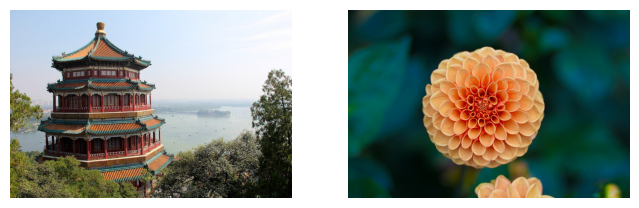

In [107]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

plt.figure(figsize=(8, 4))
for index, image in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(image)
    


In [108]:
import torchvision
import torchvision.transforms.v2 as T

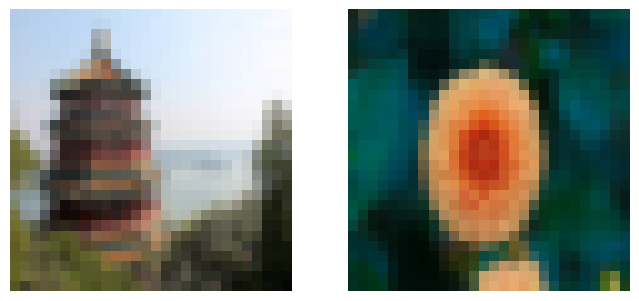

In [115]:
toTensor = T.Compose([
	T.Resize((28, 28)),
])

plt.figure(figsize=(8, 4))
for index, image in enumerate(toTensor(sample_images_permuted)):
    plt.subplot(1, 2, index + 1)
    plot_image(image)
    

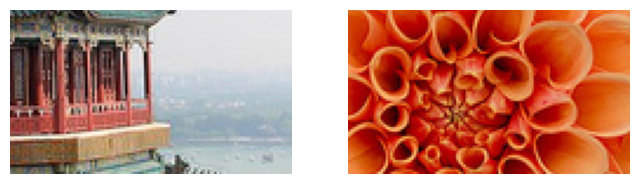

In [127]:
toTensor = T.Compose([
    # T.RandomRotation(degrees=90),
	T.CenterCrop((70,120)),
])
cropped_images = toTensor(sample_images_permuted)

plt.figure(figsize=(8, 4))
for index, image in enumerate(cropped_images):
    plt.subplot(1, 2, index + 1)
    plot_image(image)
    

# convolutional neural networks

In [131]:
conv_layer = nn.Conv2d(
    in_channels= 3,
    out_channels=32,
    kernel_size=7,
    padding='same'

)
print(cropped_images.shape)
print(conv_layer(cropped_images).shape)


torch.Size([2, 3, 70, 120])
torch.Size([2, 32, 70, 120])


In [138]:
conv_layer.weight.shape

torch.Size([32, 3, 7, 7])

In [136]:
(70 * 120 * 3) * 50

1260000